In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")



In [9]:
balanced_df = (
    df.groupby('final_emotion', group_keys=False)
      # .apply(lambda x: x.sample(555, random_state=42))
      # .apply(lambda x: x.sample(1111, random_state=42))
      .apply(lambda x: x.sample(1667, random_state=42))
      .reset_index(drop=True)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40016\2106827692.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1667, random_state=42))


In [10]:
balanced_df['final_emotion'].value_counts()


final_emotion
anger         1667
calm          1667
excitement    1667
fear          1667
joy           1667
neutral       1667
reflective    1667
romantic      1667
sadness       1667
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['cleaned_lyrics'],
    balanced_df['final_emotion'],
    test_size=0.2,
    stratify=balanced_df['final_emotion'],
    random_state=42
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.33      0.35      0.34       333
        calm       0.16      0.17      0.16       333
  excitement       0.11      0.10      0.11       334
        fear       0.23      0.22      0.23       334
         joy       0.14      0.15      0.14       334
     neutral       0.15      0.13      0.14       333
  reflective       0.13      0.11      0.12       334
    romantic       0.26      0.30      0.28       333
     sadness       0.19      0.19      0.19       333

    accuracy                           0.19      3001
   macro avg       0.19      0.19      0.19      3001
weighted avg       0.19      0.19      0.19      3001



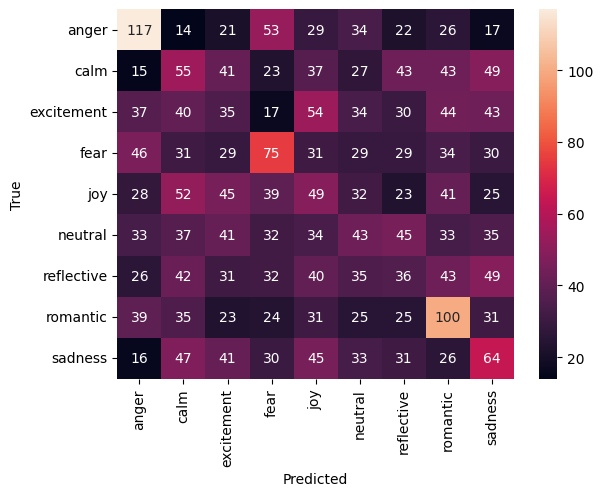

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
